# 03 — XAI y auditoría del mejor MLP validado

Este notebook carga la decisión única tomada por `02B_MLP_Heterogeneo_Keras.ipynb`. Puede auditar el baseline Keras o el MLP heterogéneo sin volver a seleccionar. El criterio es mayor PR-AUC sobre el 20% de validación (semilla 42); nunca se consulta test.

In [34]:
# ==============================
# Imports
# ==============================

from __future__ import annotations

import json
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_AVAILABLE = False
    print("SHAP no está disponible. Se usará importancia por permutación como fallback.")
    print(exc)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUTPUT_DIR = Path("outputs")
OBJECTS_DIR = OUTPUT_DIR / "objects"
MODELS_DIR = OUTPUT_DIR / "models"
XAI_DIR = OUTPUT_DIR / "xai"
XAI_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Device: cpu


## 1. Carga de datos, modelos y metadatos

Este notebook requiere haber ejecutado:

1. `01_EDA_Preprocesado.ipynb`
2. `02_Modelado_RL_NN.ipynb`

Se cargan los modelos finales y se reconstruyen las clases PyTorch con la misma arquitectura usada durante entrenamiento.

In [35]:
import importlib
import utils.heterogeneous_mlp as heterogeneous_utils
heterogeneous_utils = importlib.reload(heterogeneous_utils)
load_selection_manifest = heterogeneous_utils.load_selection_manifest
load_keras_model_from_manifest = heterogeneous_utils.load_keras_model_from_manifest
predict_selected_proba = heterogeneous_utils.predict_selected_proba
verify_runtime_contract = heterogeneous_utils.verify_runtime_contract
required_files=[OUTPUT_DIR/'preprocessed_train.csv',MODELS_DIR/'mlp_selection_manifest.json']
for path in required_files:
    if not path.exists(): raise FileNotFoundError(f'Falta {path}. Ejecuta 01, 02 y 02B.')
train_df=pd.read_csv(OUTPUT_DIR/'preprocessed_train.csv'); manifest=load_selection_manifest()
TARGET='SeriousDlqin2yrs'; FEATURES=manifest['preprocessing_spec']['features']
X=train_df[FEATURES].astype(float); y=train_df[TARGET].astype(int)
audit_model=load_keras_model_from_manifest(manifest); verify_runtime_contract(audit_model,X,manifest)
model_metadata={'scenarios':manifest['scenarios'],'selected_models':{s:{'model_family':'KerasMLP',
 'model_file':manifest['selected_model']['model_file'],'threshold':manifest['thresholds'][s]} for s in manifest['scenarios']}}
print('Modelo seleccionado una sola vez:',manifest['selected_model']['name'])
print('Criterio:',manifest['selection_rule'],manifest['validation_scores'])

Modelo seleccionado una sola vez: heterogeneous_mlp
Criterio: max validation PR-AUC; ties keep baseline {'baseline_keras': 0.37588281250883, 'heterogeneous_mlp': 0.3980583669131988}


In [36]:
def predict_model_score(model, model_family, X_array, batch_size=4096):
    frame=X_array if isinstance(X_array,pd.DataFrame) else pd.DataFrame(X_array,columns=FEATURES)
    return predict_selected_proba(model,frame,manifest,batch_size)
def predict_selected_scenario(scenario,X_raw):
    selected=model_metadata['selected_models'][scenario]
    score=predict_selected_proba(audit_model,X_raw[FEATURES],manifest)
    return score,(score>=selected['threshold']).astype(int),selected
class IdentityScaler:
    def transform(self,z): return np.asarray(z,dtype=float)
scaler=IdentityScaler(); X_scaled=scaler.transform(X)

In [37]:
# Calculamos predicciones para ambos escenarios.
scenario_predictions = {}
for scenario in model_metadata["scenarios"].keys():
    score, pred, selected = predict_selected_scenario(scenario, X)
    scenario_predictions[scenario] = {"score": score, "pred": pred, "selected": selected}
    print("\nEscenario:", scenario)
    print("Modelo:", selected)
    print("AUC aproximado:", roc_auc_score(y, score))
    display(pd.DataFrame(confusion_matrix(y, pred, labels=[0, 1]), index=["real_0", "real_1"], columns=["pred_0", "pred_1"]))


Escenario: cost_1_1
Modelo: {'model_family': 'KerasMLP', 'model_file': 'heterogeneous_mlp_final.keras', 'threshold': 0.9108080808080807}
AUC aproximado: 0.8728599428698478


,pred_0,pred_1
real_0,96882,772
real_1,5785,1230



Escenario: cost_1_10
Modelo: {'model_family': 'KerasMLP', 'model_file': 'heterogeneous_mlp_final.keras', 'threshold': 0.5296969696969697}
AUC aproximado: 0.8728599428698478


,pred_0,pred_1
real_0,80252,17402
real_1,1662,5353


## 2. Selección del modelo a auditar

Auditaremos principalmente el escenario `cost_1_10`, porque es el más sensible desde el punto de vista de riesgo: equivocarse concediendo crédito a un cliente que acaba en mora grave cuesta diez veces más que rechazar a un cliente bueno.

Aun así, el código permite cambiar `AUDIT_SCENARIO` a `cost_1_1`.

In [38]:
AUDIT_SCENARIO='cost_1_10'
audit_score=scenario_predictions[AUDIT_SCENARIO]['score']; audit_pred=scenario_predictions[AUDIT_SCENARIO]['pred']
audit_selected=scenario_predictions[AUDIT_SCENARIO]['selected']; audit_family='KerasMLP'
audit_threshold=audit_selected['threshold']; audit_checkpoint={'model_type':manifest['selected_model']['name']}
print('Escenario:',AUDIT_SCENARIO,'| modelo:',manifest['selected_model']['name'],'| threshold:',audit_threshold)
print('Selección motivada por PR-AUC validación:',manifest['validation_scores'])

Escenario: cost_1_10 | modelo: heterogeneous_mlp | threshold: 0.5296969696969697
Selección motivada por PR-AUC validación: {'baseline_keras': 0.37588281250883, 'heterogeneous_mlp': 0.3980583669131988}


## 3. Modelo subrogado interpretable

Un modelo subrogado intenta imitar el comportamiento del modelo caja negra, no el target real directamente.

Aquí entrenamos un árbol de decisión pequeño con `max_depth=3` para aproximar las decisiones del modelo auditado. El objetivo es extraer reglas sencillas del tipo:

> Si el número de retrasos de 90 días es alto y la utilización de crédito es alta, entonces el modelo tiende a clasificar como alto riesgo.

La métrica importante del subrogado es la **fidelidad**, es decir, cuánto coincide con la caja negra.

In [39]:
# Dividimos para medir fidelidad fuera de la muestra usada por el subrogado.
X_sur_train, X_sur_test, y_sur_train, y_sur_test = train_test_split(
    X,
    audit_pred,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=audit_pred,
)

surrogate_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=300,
    random_state=RANDOM_STATE,
)
surrogate_tree.fit(X_sur_train, y_sur_train)

sur_pred = surrogate_tree.predict(X_sur_test)
fidelity = accuracy_score(y_sur_test, sur_pred)

print("Fidelidad del árbol subrogado respecto al modelo caja negra:", round(fidelity, 4))
print(classification_report(y_sur_test, sur_pred, digits=4, zero_division=0))

Fidelidad del árbol subrogado respecto al modelo caja negra: 0.925
              precision    recall  f1-score   support

           0     0.9362    0.9702    0.9529     20479
           1     0.8767    0.7622    0.8154      5689

    accuracy                         0.9250     26168
   macro avg     0.9065    0.8662    0.8842     26168
weighted avg     0.9233    0.9250    0.9230     26168



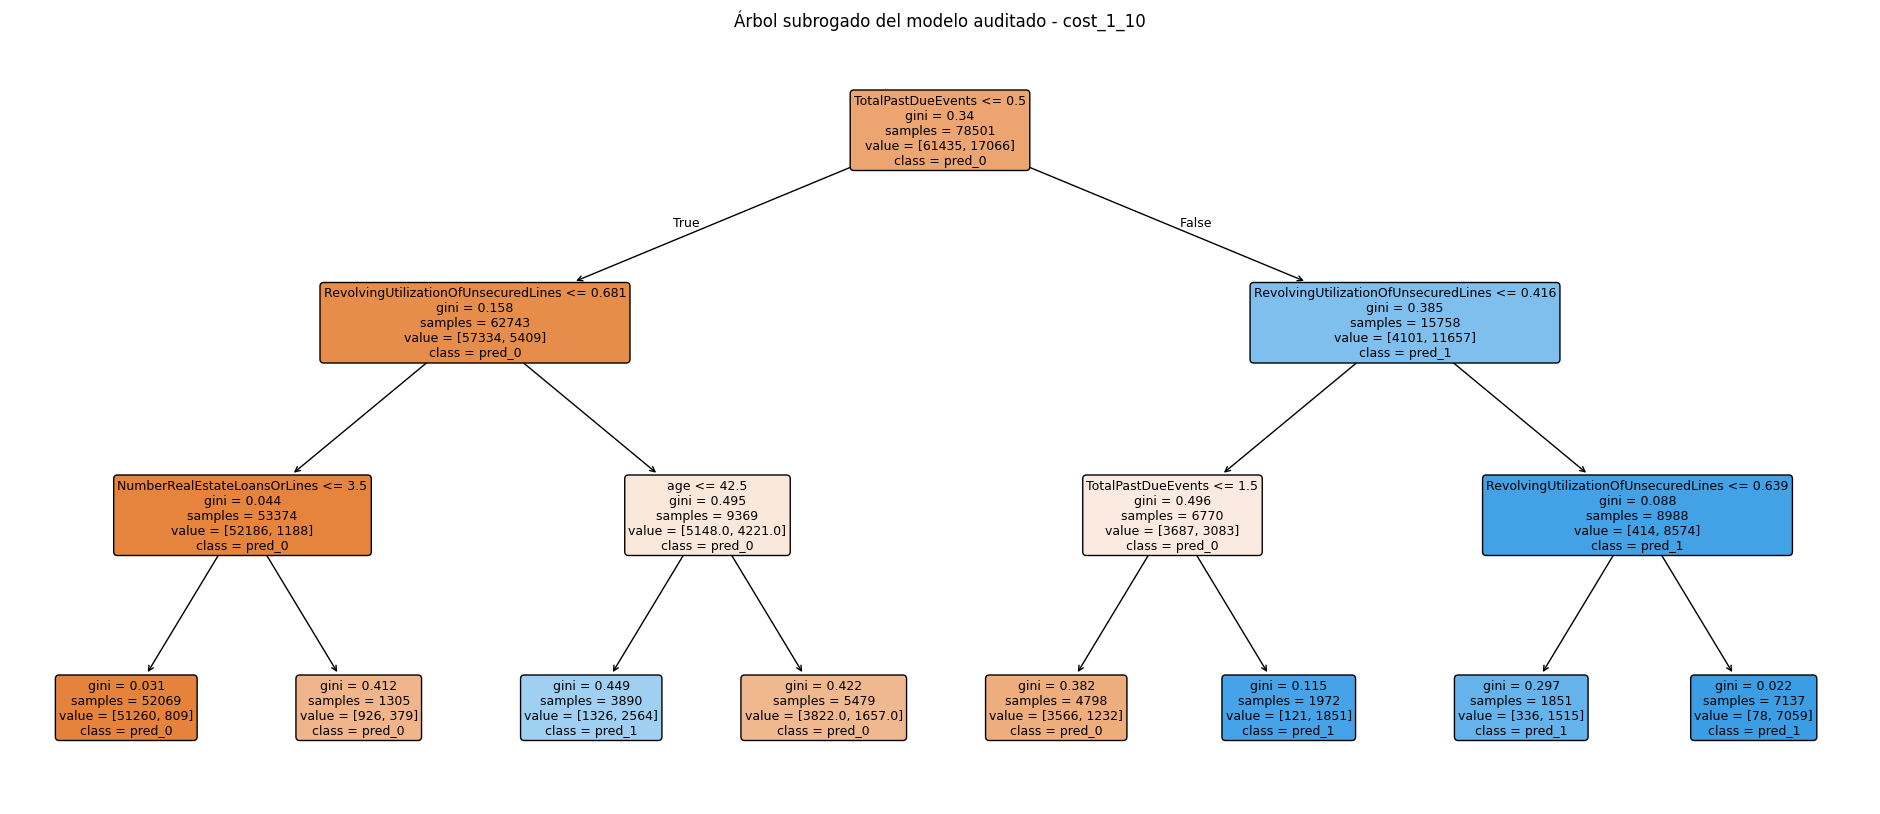

In [40]:
plt.figure(figsize=(24, 10))
plot_tree(
    surrogate_tree,
    feature_names=FEATURES,
    class_names=["pred_0", "pred_1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title(f"Árbol subrogado del modelo auditado - {AUDIT_SCENARIO}")
plt.show()

In [41]:
rules_text = export_text(surrogate_tree, feature_names=FEATURES, decimals=3)
print(rules_text)

with open(XAI_DIR / f"surrogate_rules_{AUDIT_SCENARIO}.txt", "w", encoding="utf-8") as f:
    f.write(rules_text)

print("Reglas guardadas en:", XAI_DIR / f"surrogate_rules_{AUDIT_SCENARIO}.txt")

|--- TotalPastDueEvents <= 0.500
|   |--- RevolvingUtilizationOfUnsecuredLines <= 0.681
|   |   |--- NumberRealEstateLoansOrLines <= 3.500
|   |   |   |--- class: 0
|   |   |--- NumberRealEstateLoansOrLines >  3.500
|   |   |   |--- class: 0
|   |--- RevolvingUtilizationOfUnsecuredLines >  0.681
|   |   |--- age <= 42.500
|   |   |   |--- class: 1
|   |   |--- age >  42.500
|   |   |   |--- class: 0
|--- TotalPastDueEvents >  0.500
|   |--- RevolvingUtilizationOfUnsecuredLines <= 0.416
|   |   |--- TotalPastDueEvents <= 1.500
|   |   |   |--- class: 0
|   |   |--- TotalPastDueEvents >  1.500
|   |   |   |--- class: 1
|   |--- RevolvingUtilizationOfUnsecuredLines >  0.416
|   |   |--- RevolvingUtilizationOfUnsecuredLines <= 0.639
|   |   |   |--- class: 1
|   |   |--- RevolvingUtilizationOfUnsecuredLines >  0.639
|   |   |   |--- class: 1

Reglas guardadas en: outputs\xai\surrogate_rules_cost_1_10.txt


Con un 92.5% de fidelidad, un árbol de solo 3 niveles reproduce casi todas las decisiones de la MLP. Esto sugiere que, aunque el modelo es una red neuronal "caja negra", las reglas que efectivamente usa para decidir no son tan complejas. son mayoritariamente combinaciones de pocos contadores de retraso de pago. Es una buena noticia para la interpretabilidad, aunque el 7.5% restante (donde el subrogado se equivoca) recuerda que las reglas simples no capturan toda la sutileza del modelo real.

### 3.1 Comparación: subrogado para `cost_1_1`

SHAP y la importancia por permutación no cambian entre escenarios (explican
al mismo modelo, la MLP, con el mismo score). **Pero el árbol subrogado sí
puede cambiar**, porque aprende a imitar la *decisión* (score >= threshold),
y el threshold es distinto en cada escenario. Por eso esta es la pieza que sí vale la pena repetir
para el otro escenario, en vez de asumir que "sale igual".


In [42]:
pred_cost_1_1 = scenario_predictions["cost_1_1"]["pred"]

X_sur_train_11, X_sur_test_11, y_sur_train_11, y_sur_test_11 = train_test_split(
    X,
    pred_cost_1_1,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=pred_cost_1_1,
)

surrogate_tree_cost_1_1 = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=300,
    random_state=RANDOM_STATE,
)
surrogate_tree_cost_1_1.fit(X_sur_train_11, y_sur_train_11)

sur_pred_11 = surrogate_tree_cost_1_1.predict(X_sur_test_11)
fidelity_cost_1_1 = accuracy_score(y_sur_test_11, sur_pred_11)

print(f"Fidelidad del subrogado para cost_1_1: {fidelity_cost_1_1:.4f}")
print(f"Fidelidad del subrogado para cost_1_10 (sección 3): {fidelity:.4f}")

fidelity_comparison = pd.DataFrame({
    "escenario": ["cost_1_1", "cost_1_10"],
    "threshold": [
        model_metadata["selected_models"]["cost_1_1"]["threshold"],
        model_metadata["selected_models"]["cost_1_10"]["threshold"],
    ],
    "fidelidad_subrogado": [fidelity_cost_1_1, fidelity],
})
display(fidelity_comparison)


Fidelidad del subrogado para cost_1_1: 0.9907
Fidelidad del subrogado para cost_1_10 (sección 3): 0.9250


,escenario,threshold,fidelidad_subrogado
0,cost_1_1,0.9108,0.9907
1,cost_1_10,0.5297,0.9250


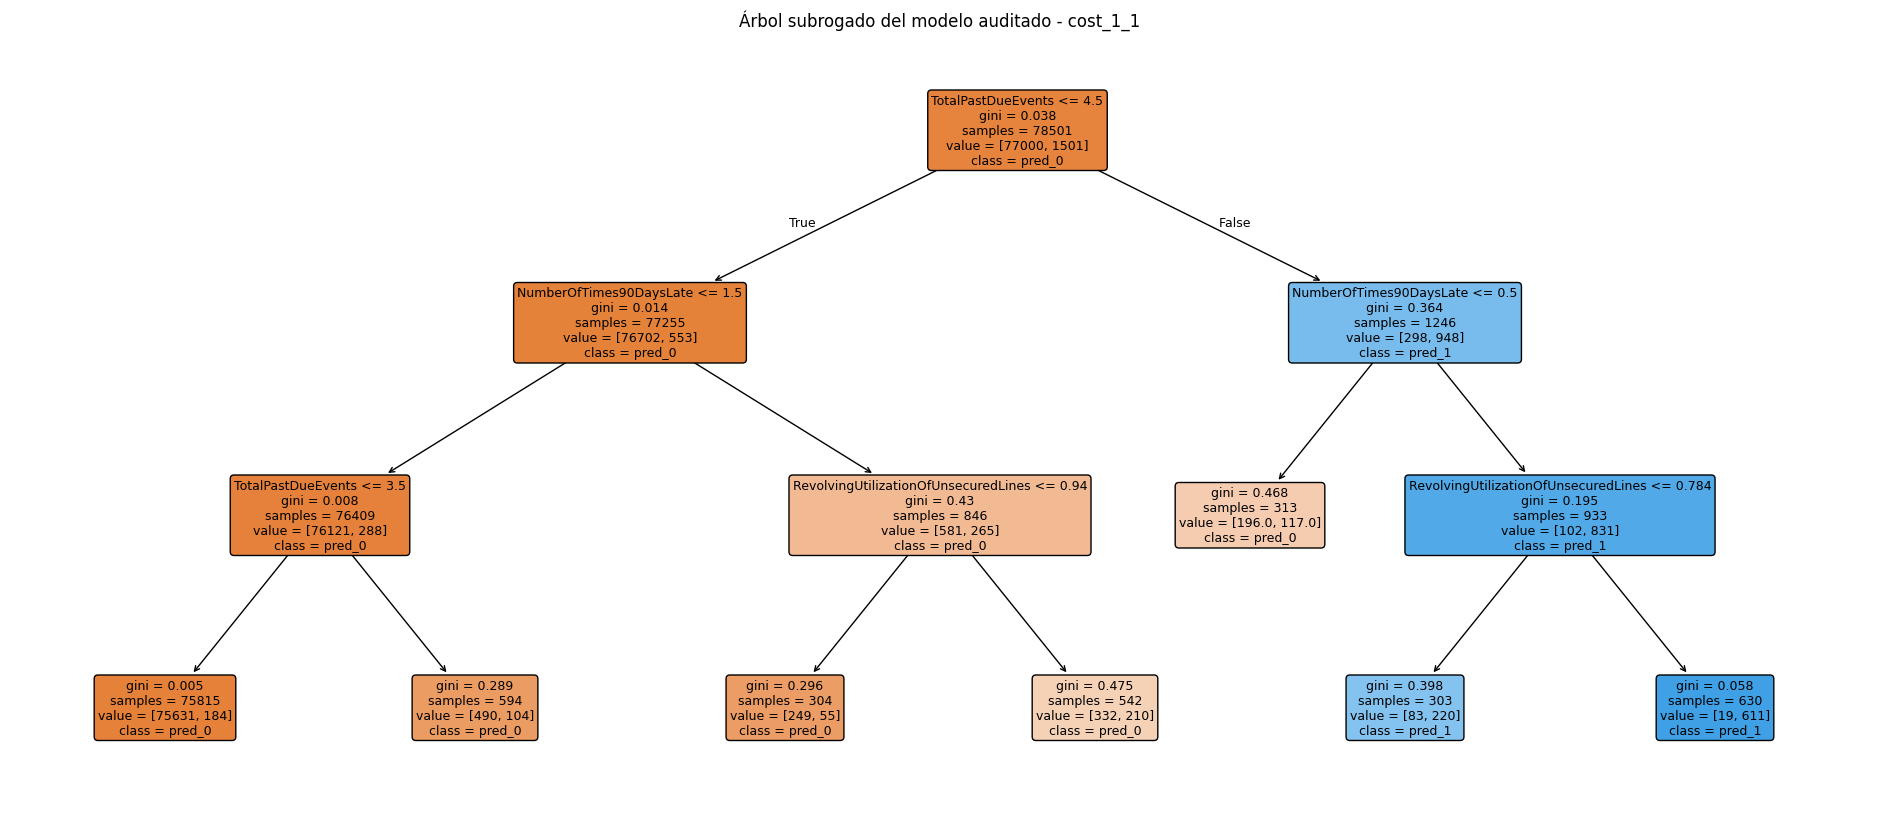

|--- TotalPastDueEvents <= 4.500
|   |--- NumberOfTimes90DaysLate <= 1.500
|   |   |--- TotalPastDueEvents <= 3.500
|   |   |   |--- class: 0
|   |   |--- TotalPastDueEvents >  3.500
|   |   |   |--- class: 0
|   |--- NumberOfTimes90DaysLate >  1.500
|   |   |--- RevolvingUtilizationOfUnsecuredLines <= 0.940
|   |   |   |--- class: 0
|   |   |--- RevolvingUtilizationOfUnsecuredLines >  0.940
|   |   |   |--- class: 0
|--- TotalPastDueEvents >  4.500
|   |--- NumberOfTimes90DaysLate <= 0.500
|   |   |--- class: 0
|   |--- NumberOfTimes90DaysLate >  0.500
|   |   |--- RevolvingUtilizationOfUnsecuredLines <= 0.784
|   |   |   |--- class: 1
|   |   |--- RevolvingUtilizationOfUnsecuredLines >  0.784
|   |   |   |--- class: 1



In [43]:
plt.figure(figsize=(24, 10))
plot_tree(
    surrogate_tree_cost_1_1,
    feature_names=FEATURES,
    class_names=["pred_0", "pred_1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Árbol subrogado del modelo auditado - cost_1_1")
plt.show()

rules_text_cost_1_1 = export_text(surrogate_tree_cost_1_1, feature_names=FEATURES, decimals=3)
print(rules_text_cost_1_1)

with open(XAI_DIR / "surrogate_rules_cost_1_1.txt", "w", encoding="utf-8") as f:
    f.write(rules_text_cost_1_1)


El subrogado explica mejor las decisiones en `cost_1_1` que en `cost_1_10`. No es que el modelo sea "más simple" en un escenario que en otro (es la misma MLP), es que con un threshold muy alto casi nadie cruza la línea, así que la regla que separa "denegado" de "aprobado" es más fácil de resumir en un árbol pequeño. Con un threshold más bajo hay más casos cerca de la frontera, con más matices que un árbol de profundidad 3 no puede capturar del todo.

## 4. Importancia global por permutación

La importancia por permutación mide cuánto empeora el modelo si rompemos aleatoriamente una variable. Si al permutar una variable el score del modelo empeora mucho, significa que el modelo dependía bastante de esa variable.

Para evitar tiempos excesivos, usamos una muestra.

In [44]:
class BlackBoxWrapper(ClassifierMixin, BaseEstimator):
    """
    Wrapper estilo sklearn para poder usar permutation_importance.

    Hereda de BaseEstimator/ClassifierMixin porque sklearn >= 1.3 valida
    internamente "tags" del estimador (__sklearn_tags__) antes de calcular
    la importancia por permutación; sin esa herencia, la validación falla
    aunque el wrapper funcione perfectamente bien.
    """
    def __init__(self, model, model_family: str, threshold: float):
        self.model = model
        self.model_family = model_family
        self.threshold = threshold
        # sklearn exige que un clasificador exponga classes_ (aunque nunca
        # se llame a fit de verdad, ya que el modelo ya viene entrenado).
        self.classes_ = np.array([0, 1])

    def fit(self, X_input=None, y_input=None):
        # No-op: el modelo ya viene entrenado desde el notebook 02.
        # sklearn >= 1.3 exige que permutation_importance reciba un
        # estimador con método fit (aunque nunca llegue a invocarlo),
        # así que lo añadimos solo para pasar esa validación.
        return self

    def predict_proba(self, X_input):
        if isinstance(X_input, pd.DataFrame):
            X_arr = scaler.transform(X_input[FEATURES].astype(float))
        else:
            X_arr = scaler.transform(pd.DataFrame(X_input, columns=FEATURES).astype(float))
        score = predict_model_score(self.model, self.model_family, X_arr)
        return np.vstack([1 - score, score]).T

    def predict(self, X_input):
        return (self.predict_proba(X_input)[:, 1] >= self.threshold).astype(int)

    def score(self, X_input, y_input):
        return roc_auc_score(y_input, self.predict_proba(X_input)[:, 1])


blackbox = BlackBoxWrapper(audit_model, audit_family, audit_threshold)

perm_sample_idx = X.sample(n=min(8000, len(X)), random_state=RANDOM_STATE).index
X_perm = X.loc[perm_sample_idx]
y_perm = y.loc[perm_sample_idx]

perm = permutation_importance(
    blackbox,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

perm_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_importance.head(20)

,feature,importance_mean,importance_std
0,RevolvingUtilizationOfUnsecuredLines,0.0807,0.0052
2,NumberOfTime30-59DaysPastDueNotWorse,0.0195,0.0017
6,NumberOfTimes90DaysLate,0.0173,0.0014
7,NumberRealEstateLoansOrLines,0.0141,0.0011
8,NumberOfTime60-89DaysPastDueNotWorse,0.0137,0.0009
1,age,0.0124,0.0023
14,TotalPastDueEvents,0.0087,0.0008
5,NumberOfOpenCreditLinesAndLoans,0.0074,0.0020
4,MonthlyIncome,0.0048,0.0003
15,CreditLinesPerRealEstateLoan,0.0043,0.0008


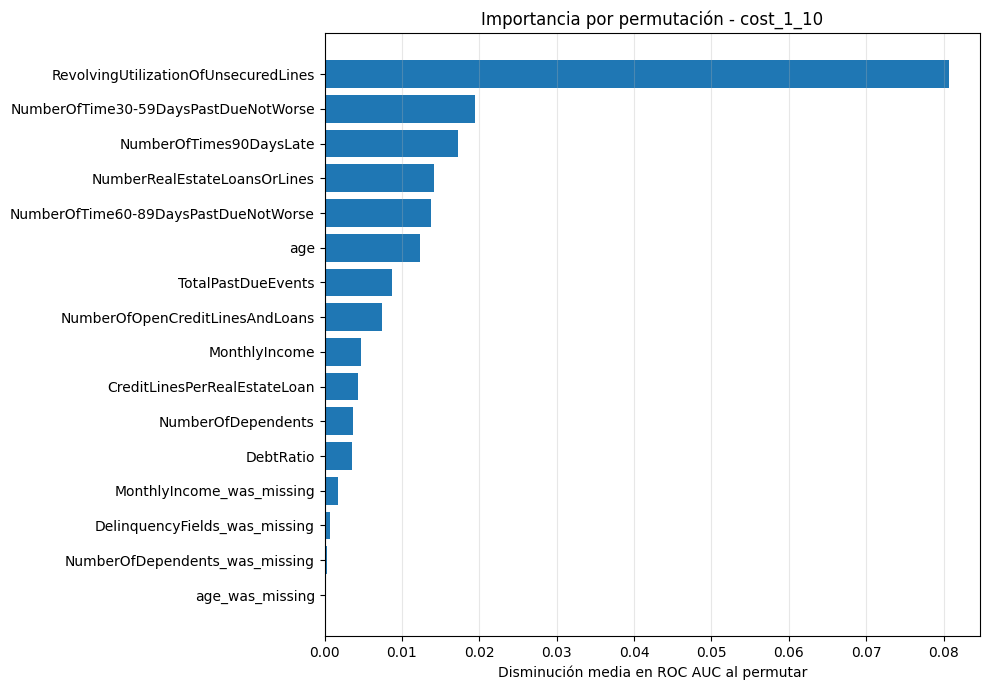

In [45]:
plt.figure(figsize=(10, 7))
top_perm = perm_importance.head(20).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"Importancia por permutación - {AUDIT_SCENARIO}")
plt.xlabel("Disminución media en ROC AUC al permutar")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

perm_importance.to_csv(XAI_DIR / f"permutation_importance_{AUDIT_SCENARIO}.csv", index=False)

## 4.1 Partial Dependence Plots (PDP)

SHAP y la importancia por permutación dicen **qué tan importante** es una
variable. El PDP responde una pregunta distinta y complementaria: **en qué
dirección y con qué forma** afecta esa variable a la predicción, en promedio,
si la vamos moviendo de un extremo a otro y dejamos las demás variables
como están.

La calculamos para las 4 variables más importantes según la
sección 4 (permutation importance), reutilizando el mismo `blackbox` ya
creado (no hace falta ningún modelo ni cálculo nuevo).


Variables para PDP (top 4 por permutation importance): ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines']


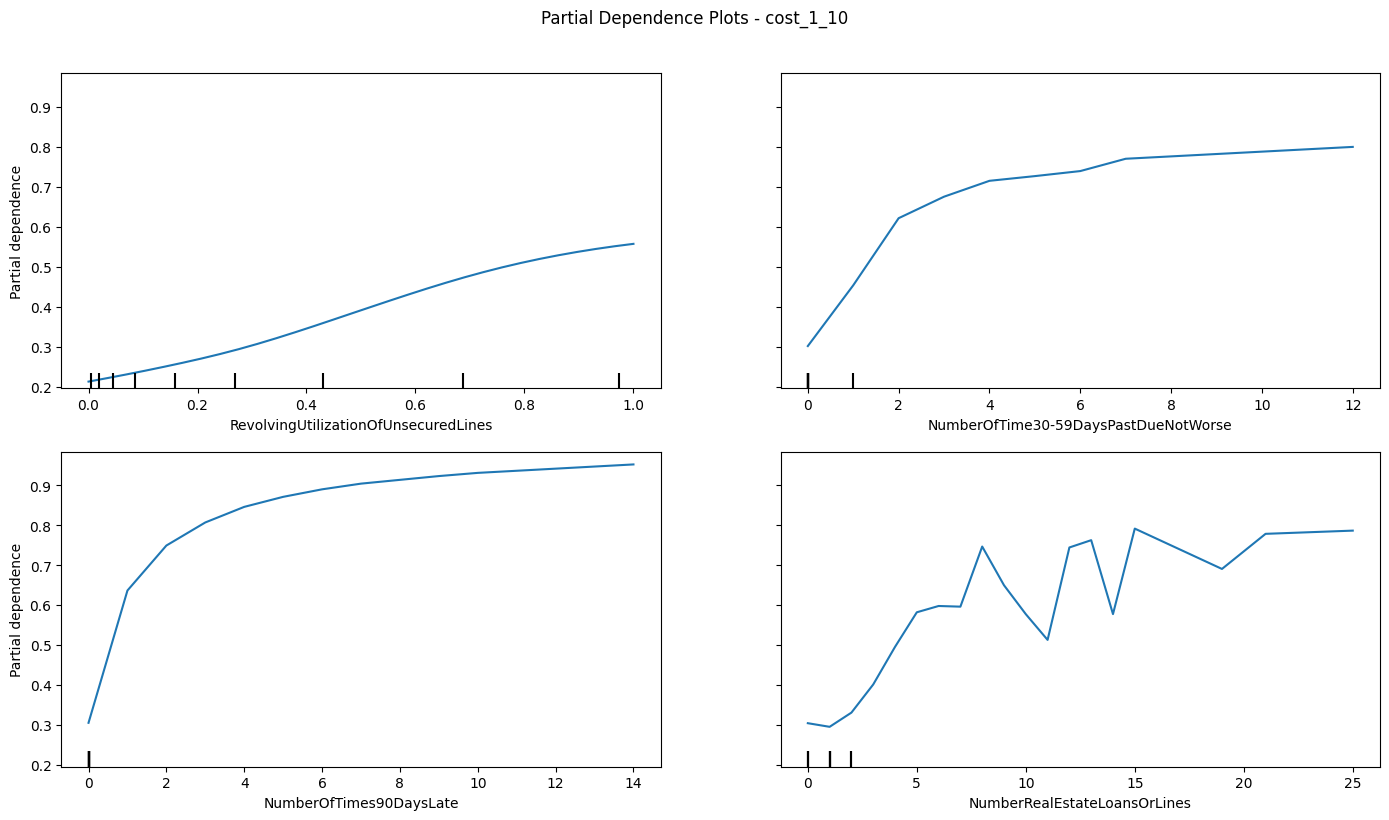

In [46]:
from sklearn.inspection import PartialDependenceDisplay

top_pdp_features = perm_importance.head(4)["feature"].tolist()
print("Variables para PDP (top 4 por permutation importance):", top_pdp_features)

# Usamos una muestra (no las 104.000 filas) para que el cálculo sea rápido;
# es práctica habitual con PDP, el resultado no cambia apenas con más filas.
X_pdp_sample = X.sample(n=min(5000, len(X)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    blackbox,
    X_pdp_sample,
    features=top_pdp_features,
    kind="average",
    target=1,
    ax=ax,
    n_cols=2,
    grid_resolution=30,
)
fig.suptitle(f"Partial Dependence Plots - {AUDIT_SCENARIO}", y=1.02)
plt.tight_layout()
plt.show()


Los gráficos de **Partial Dependence (PDP)** muestran el efecto marginal de cada variable sobre la probabilidad predicha de impago por el modelo, manteniendo el resto de variables constantes. En general, se observa que las variables relacionadas con el historial de morosidad son las que ejercen una mayor influencia sobre la predicción.

En **RevolvingUtilizationOfUnsecuredLines** se aprecia una relación creciente y prácticamente monótona: a medida que aumenta la utilización de las líneas de crédito no garantizadas, también aumenta la probabilidad estimada de impago. El crecimiento es gradual en todo el rango de valores, lo que sugiere que el modelo considera esta variable como un indicador continuo de riesgo financiero.

Las variables **NumberOfTime30-59DaysPastDueNotWorse** y **NumberOfTimes90DaysLate** presentan un comportamiento mucho más pronunciado. El riesgo aumenta de forma muy rápida tras los primeros retrasos en los pagos y posteriormente tiende a estabilizarse, indicando un efecto de saturación. En particular, los primeros incumplimientos aportan una gran cantidad de información al modelo, mientras que acumular retrasos adicionales incrementa el riesgo en menor medida.

Por su parte, **NumberRealEstateLoansOrLines** muestra una relación menos estable. Aunque la tendencia general es creciente, aparecen oscilaciones para determinados valores debido a la escasez de observaciones en esas regiones del espacio de características. Aun así, el modelo parece asociar un mayor número de préstamos o líneas inmobiliarias con una mayor probabilidad de impago, especialmente a partir de valores intermedios.

En conjunto, estos PDP indican que el modelo ha aprendido relaciones coherentes con el dominio financiero: un mayor nivel de utilización del crédito y un historial de retrasos en los pagos incrementan de forma significativa el riesgo de incumplimiento, siendo las variables de morosidad las que presentan el mayor impacto sobre la predicción.

## 5. SHAP global y local

SHAP descompone la predicción en aportaciones por variable. Para modelos neuronales tabulares, `KernelExplainer` es más general pero más lento. Por eso usamos muestras pequeñas:

- `background`: muestra usada como referencia.
- `explain_sample`: clientes concretos que explicamos.

In [47]:
# Función que SHAP puede llamar: recibe datos en escala original y devuelve probabilidad de clase 1.
def shap_predict_proba(x_numpy: np.ndarray) -> np.ndarray:
    x_df = pd.DataFrame(x_numpy, columns=FEATURES)
    x_scaled = scaler.transform(x_df.astype(float))
    return predict_model_score(audit_model, audit_family, x_scaled)

# Muestras para SHAP.
background = X.sample(n=min(100, len(X)), random_state=RANDOM_STATE)
explain_sample = X.sample(n=min(300, len(X)), random_state=RANDOM_STATE + 1)

print("Background SHAP:", background.shape)
print("Muestra a explicar:", explain_sample.shape)

Background SHAP: (100, 16)
Muestra a explicar: (300, 16)


In [48]:
if SHAP_AVAILABLE:
    # KernelExplainer es lento pero válido para cualquier caja negra.
    explainer = shap.KernelExplainer(shap_predict_proba, background)
    shap_values = explainer.shap_values(explain_sample, nsamples=100)

    # En algunas versiones shap_values puede venir como lista; normalizamos.
    if isinstance(shap_values, list):
        shap_values_array = shap_values[0]
    else:
        shap_values_array = shap_values

    print("SHAP values shape:", np.array(shap_values_array).shape)
else:
    shap_values_array = None

100%|██████████| 300/300 [01:04<00:00,  4.65it/s]

SHAP values shape: (300, 16)


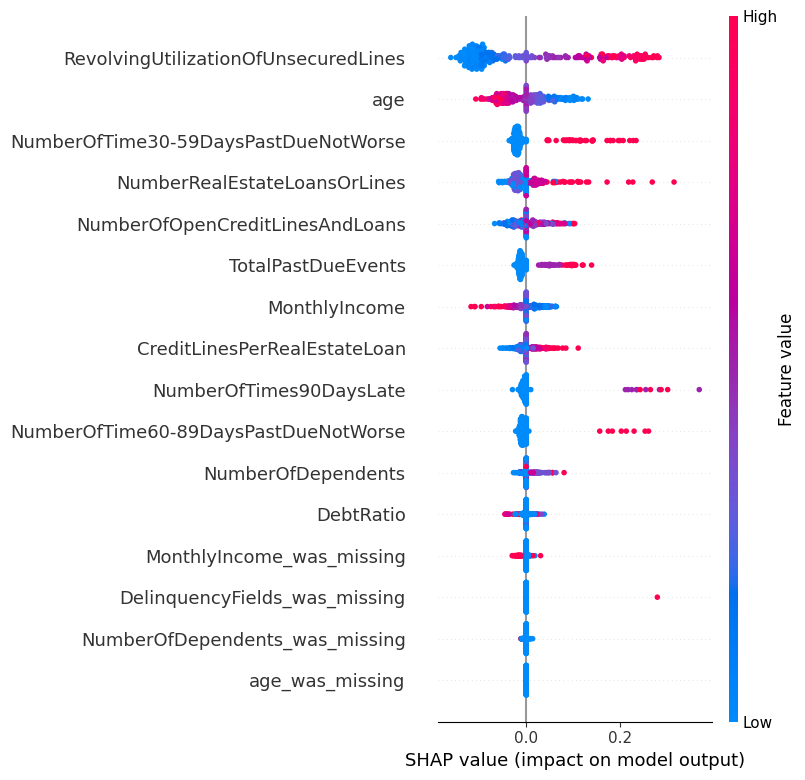

In [49]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap.summary_plot(shap_values_array, explain_sample, feature_names=FEATURES, show=True)

In [50]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap.summary_plot(shap_values_array, explain_sample, feature_names=FEATURES, plot_type="bar", show=True)

KeyboardInterrupt: 

In [ ]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap_global = pd.DataFrame({
        "feature": FEATURES,
        "mean_abs_shap": np.abs(shap_values_array).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    display(shap_global.head(20))
    shap_global.to_csv(XAI_DIR / f"shap_global_{AUDIT_SCENARIO}.csv", index=False)
else:
    shap_global = perm_importance.rename(columns={"importance_mean": "mean_abs_shap"})[["feature", "mean_abs_shap"]]

,feature,mean_abs_shap
0,RevolvingUtilizationOfUnsecuredLines,0.1155
1,age,0.0422
2,NumberOfTime30-59DaysPastDueNotWorse,0.0325
7,NumberRealEstateLoansOrLines,0.0265
5,NumberOfOpenCreditLinesAndLoans,0.0254
14,TotalPastDueEvents,0.0209
4,MonthlyIncome,0.0207
15,CreditLinesPerRealEstateLoan,0.0148
6,NumberOfTimes90DaysLate,0.0144
8,NumberOfTime60-89DaysPastDueNotWorse,0.0128


Confirma lo mismo que la importancia por permutación — `age` y los contadores de retrasos de pago dominan. La diferencia es que SHAP también muestra la *dirección*: los retrasos empujan siempre hacia más riesgo, mientras que la edad empuja hacia menos riesgo (consistente con el PDP de la sección 4.1).

### 5.1 Explicaciones locales

Antes se cogían solo los casos más "claros" de cada clase (score más alto en
cada grupo). Aquí mezclamos varios tipos de caso, porque cada uno enseña algo
distinto:

- **Clase 0, score alto** (2 casos): buenos pagadores a los que el modelo ve
  como arriesgados — posibles falsos positivos, interesante para ver si el
  modelo es "injusto" en algún perfil concreto.
- **Clase 1, score alto** (2 casos): morosos reales que el modelo detecta con
  claridad — casos donde el modelo acierta y es fácil de explicar.
- **Clase 1, score bajo** (2 casos): morosos reales que el modelo **no**
  detecta — falsos negativos. Son el error más caro en el escenario
  `FP=1, FN=10`, así que merece la pena ver qué tienen en común los casos que
  se le escapan al modelo.
- **Casos límite** (2 casos, de cualquier clase real): los que tienen el
  score más cercano al threshold de decisión — son los más útiles para
  contrafactuales, porque necesitan pocos cambios para cruzar la frontera.

Esto sirve para responder a preguntas del tipo:

> ¿Por qué se me ha denegado el crédito?

pero también para auditar honestamente dónde falla el modelo, no solo
enseñar sus aciertos.


In [ ]:
# Elegimos ejemplos reales de cada clase, mezclando casos claros y casos
# límite/fallos (en vez de solo los casos más "obvios").
examples_0 = train_df[y == 0].copy()
examples_1 = train_df[y == 1].copy()

examples_0["score"] = audit_score[y == 0]
examples_1["score"] = audit_score[y == 1]

# 1) Clase 0 con score alto: buenos pagadores que el modelo ve como
#    arriesgados -> posibles falsos positivos.
case_class0_high = examples_0.sort_values("score", ascending=False).head(2).copy()
case_class0_high["case_type"] = "clase_0_score_alto (posible falso positivo)"

# 2) Clase 1 con score alto: morosos reales detectados con claridad.
case_class1_high = examples_1.sort_values("score", ascending=False).head(2).copy()
case_class1_high["case_type"] = "clase_1_score_alto (acierto claro)"

# 3) Clase 1 con score bajo: morosos reales que el modelo NO detecta
#    -> falsos negativos, el error más caro en el escenario FP=1,FN=10.
case_class1_low = examples_1.sort_values("score", ascending=True).head(2).copy()
case_class1_low["case_type"] = "clase_1_score_bajo (falso negativo)"

# 4) Casos límite: score más cercano al threshold de decisión, de cualquier
#    clase real -> los más útiles para contrafactuales (pocos cambios
#    necesarios para cruzar la frontera).
all_examples = pd.concat([examples_0, examples_1])
all_examples["dist_to_threshold"] = (all_examples["score"] - audit_threshold).abs()
case_borderline = all_examples.sort_values("dist_to_threshold", ascending=True).head(2).copy()
case_borderline["case_type"] = "caso_limite (cerca del threshold)"

local_cases_df = pd.concat([
    case_class0_high, case_class1_high, case_class1_low, case_borderline
])

local_indices = local_cases_df.index.tolist()
local_cases = X.loc[local_indices].copy()
local_scores = audit_score[local_indices]
local_preds = audit_pred[local_indices]
local_true = y.loc[local_indices].values

local_summary = pd.DataFrame({
    "index": local_indices,
    "case_type": local_cases_df["case_type"].values,
    "true_class": local_true,
    "model_score_class_1": local_scores,
    "model_prediction": local_preds,
})
local_summary


,index,case_type,true_class,model_score_class_1,model_prediction
0,12013,clase_0_score_alto (posible falso positivo),0,0.9908,1
1,496,clase_0_score_alto (posible falso positivo),0,0.9888,1
2,53957,clase_1_score_alto (acierto claro),1,0.9962,1
3,92755,clase_1_score_alto (acierto claro),1,0.9936,1
4,26131,clase_1_score_bajo (falso negativo),1,0.0322,0
5,12029,clase_1_score_bajo (falso negativo),1,0.0355,0
6,49607,caso_limite (cerca del threshold),0,0.5297,0
7,71278,caso_limite (cerca del threshold),0,0.5297,1


In [ ]:
if SHAP_AVAILABLE:
    local_shap_values = explainer.shap_values(local_cases, nsamples=200)
    if isinstance(local_shap_values, list):
        local_shap_values = local_shap_values[0]

    for i, idx in enumerate(local_indices):
        print("\nCaso index:", idx, "| real:", local_true[i], "| pred:", local_preds[i], "| score:", round(local_scores[i], 4))
        contrib = pd.DataFrame({
            "feature": FEATURES,
            "value": local_cases.iloc[i].values,
            "shap_value": local_shap_values[i],
            "abs_shap": np.abs(local_shap_values[i]),
        }).sort_values("abs_shap", ascending=False)
        display(contrib.head(10))
else:
    print("SHAP no disponible; usa la importancia por permutación y el subrogado para explicación global/local.")

100%|██████████| 8/8 [00:01<00:00,  5.13it/s]


Caso index: 12013 | real: 0 | pred: 1 | score: 0.9908


,feature,value,shap_value,abs_shap
6,NumberOfTimes90DaysLate,9.0000,0.2845,0.2845
8,NumberOfTime60-89DaysPastDueNotWorse,4.0000,0.1907,0.1907
0,RevolvingUtilizationOfUnsecuredLines,0.9386,0.0953,0.0953
14,TotalPastDueEvents,14.0000,0.0786,0.0786
4,MonthlyIncome,"2,540.9054",0.0206,0.0206
2,NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.0201,0.0201
9,NumberOfDependents,0.0000,-0.0200,0.0200
1,age,44.0000,0.0191,0.0191
12,NumberOfDependents_was_missing,0.0000,-0.0127,0.0127
7,NumberRealEstateLoansOrLines,0.0000,0.0095,0.0095



Caso index: 496 | real: 0 | pred: 1 | score: 0.9888


,feature,value,shap_value,abs_shap
6,NumberOfTimes90DaysLate,15.0000,0.3836,0.3836
0,RevolvingUtilizationOfUnsecuredLines,2.2290,0.1373,0.1373
14,TotalPastDueEvents,16.0000,0.1054,0.1054
2,NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.0549,0.0549
1,age,34.0000,0.0305,0.0305
12,NumberOfDependents_was_missing,0.0000,-0.0134,0.0134
5,NumberOfOpenCreditLinesAndLoans,2.0000,-0.0127,0.0127
4,MonthlyIncome,"3,000.0000",0.0037,0.0037
3,DebtRatio,0.0953,-0.0035,0.0035
9,NumberOfDependents,0.0000,-0.0022,0.0022


...

,feature,value,shap_value,abs_shap
0,RevolvingUtilizationOfUnsecuredLines,0.0512,-0.0997,0.0997
1,age,74.0000,-0.0476,0.0476
5,NumberOfOpenCreditLinesAndLoans,5.0000,-0.0277,0.0277
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,-0.0258,0.0258
7,NumberRealEstateLoansOrLines,1.0000,-0.0191,0.0191
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,-0.0144,0.0144
11,MonthlyIncome_was_missing,1.0000,-0.0117,0.0117
14,TotalPastDueEvents,0.0000,-0.0100,0.0100
15,CreditLinesPerRealEstateLoan,2.5000,-0.0091,0.0091
6,NumberOfTimes90DaysLate,0.0000,-0.0046,0.0046



Caso index: 49607 | real: 0 | pred: 0 | score: 0.5297


,feature,value,shap_value,abs_shap
8,NumberOfTime60-89DaysPastDueNotWorse,1.0000,0.3525,0.3525
0,RevolvingUtilizationOfUnsecuredLines,0.0242,-0.1006,0.1006
14,TotalPastDueEvents,1.0000,0.0367,0.0367
4,MonthlyIncome,"13,000.0000",-0.0343,0.0343
7,NumberRealEstateLoansOrLines,1.0000,-0.0157,0.0157
15,CreditLinesPerRealEstateLoan,6.5000,0.0116,0.0116
5,NumberOfOpenCreditLinesAndLoans,13.0000,-0.0113,0.0113
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,-0.0066,0.0066
1,age,51.0000,-0.0053,0.0053
6,NumberOfTimes90DaysLate,0.0000,-0.0024,0.0024



Caso index: 71278 | real: 0 | pred: 1 | score: 0.5297


,feature,value,shap_value,abs_shap
0,RevolvingUtilizationOfUnsecuredLines,0.7740,0.1862,0.1862
1,age,35.0000,0.0553,0.0553
9,NumberOfDependents,2.0000,0.0253,0.0253
5,NumberOfOpenCreditLinesAndLoans,3.0000,-0.0231,0.0231
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,-0.0193,0.0193
7,NumberRealEstateLoansOrLines,0.0000,0.0192,0.0192
4,MonthlyIncome,"4,084.0000",0.0166,0.0166
3,DebtRatio,0.2509,-0.0150,0.0150
14,TotalPastDueEvents,0.0000,-0.0142,0.0142
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,-0.0063,0.0063


Los ejemplos individuales analizados mediante SHAP permiten entender qué variables son responsables de las decisiones del modelo en distintos escenarios de clasificación.

### Verdaderos positivos

En los casos correctamente identificados como clientes de alto riesgo (verdaderos positivos), el modelo asigna probabilidades superiores al 99 %, lo que indica una elevada confianza en la predicción. En todos ellos destacan como principales factores **NumberOfTimes90DaysLate**, **NumberOfTime60-89DaysPastDueNotWorse**, **NumberOfTime30-59DaysPastDueNotWorse** y **TotalPastDueEvents**, todas ellas relacionadas con el historial de morosidad. Estas variables presentan valores elevados y contribuciones SHAP positivas muy importantes, incrementando notablemente la probabilidad de impago. También aparece de forma recurrente **RevolvingUtilizationOfUnsecuredLines**, indicando que una elevada utilización del crédito refuerza aún más la predicción de riesgo. Variables como la edad, los ingresos mensuales o el número de dependientes presentan contribuciones mucho menores y, en algunos casos, incluso reducen ligeramente el riesgo estimado, aunque su influencia resulta claramente secundaria frente al historial de impagos.

### Falsos negativos

Los falsos negativos corresponden a clientes que realmente incumplieron sus obligaciones pero que el modelo clasificó como solventes. En estos ejemplos se observa prácticamente la situación opuesta: no existen antecedentes relevantes de retrasos en los pagos (las variables de morosidad toman valor cero) y la utilización del crédito es muy reducida, siendo precisamente estas características las que presentan las mayores contribuciones SHAP negativas. Además, se trata de clientes de edad relativamente avanzada y con ingresos moderados o elevados, factores que también disminuyen ligeramente la probabilidad estimada de impago. Estos casos ilustran una limitación esperable del modelo: cuando un cliente carece de señales históricas de morosidad, resulta difícil anticipar un futuro incumplimiento únicamente a partir de variables demográficas o financieras.

### Verdaderos negativos

En los verdaderos negativos el modelo identifica correctamente clientes solventes, aunque con una confianza intermedia. En estos ejemplos aparecen algunos indicadores de riesgo aislados, como un retraso puntual de entre 60 y 89 días o un pequeño número de eventos de impago, que incrementan parcialmente la probabilidad estimada. Sin embargo, este efecto queda compensado por otros factores protectores, principalmente una baja utilización de las líneas de crédito, ingresos elevados, un mayor número de líneas abiertas y ausencia de retrasos graves superiores a 90 días. El modelo realiza así un balance entre evidencias a favor y en contra del riesgo, concluyendo correctamente que el cliente no pertenece a la clase de impago.

### Falsos positivos

Los falsos positivos corresponden a clientes clasificados como de alto riesgo que finalmente no incumplieron. En el ejemplo mostrado, el principal responsable es una utilización elevada de las líneas de crédito (**RevolvingUtilizationOfUnsecuredLines**), acompañada por una edad relativamente baja y algunos factores secundarios como el número de dependientes. Aunque el cliente no presenta antecedentes de morosidad significativos, la combinación de estos indicadores financieros lleva al modelo a estimar un riesgo superior al umbral de decisión. Este tipo de errores pone de manifiesto que algunas variables financieras pueden inducir al modelo a sobreestimar el riesgo en ausencia de un historial previo de impagos.

En conjunto, el análisis local confirma las conclusiones obtenidas mediante la importancia global de variables y los gráficos de dependencia parcial. Las decisiones del modelo están dominadas por el historial de morosidad, especialmente los retrasos superiores a 90 días y el número total de eventos de impago, mientras que variables como la utilización del crédito actúan como factores complementarios que modulan la probabilidad final cuando la información histórica resulta insuficiente.

## 6. Contrafactuales

Un contrafactual responde:

> ¿Qué tendría que cambiar para que el modelo cambiara su decisión?

Ejemplo: si el modelo deniega crédito, buscamos cambios razonables que hagan que pase a aprobarlo.

Implementamos una búsqueda sencilla y transparente:

1. Tomamos un cliente concreto.
2. Modificamos una variable cada vez hacia valores percentiles observados en construcción.
3. Probamos combinaciones greedy de cambios.
4. Devolvemos el primer caso que cruza el threshold.

No todas las variables son igualmente modificables. Por ejemplo, la edad no es una recomendación accionable. Por eso definimos una lista de variables candidatas más razonables.

In [ ]:
# Variables originales que permitimos modificar en los contrafactuales.
# Evitamos cambiar directamente variables derivadas o logarítmicas, porque eso generaría perfiles incoherentes.
MUTABLE_FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
]

MUTABLE_FEATURES = [c for c in MUTABLE_FEATURES if c in FEATURES]

# Para proponer cambios, usamos percentiles reales observados en construcción.
percentile_grid = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
feature_quantiles = {
    col: X[col].quantile(percentile_grid).values
    for col in MUTABLE_FEATURES
}


def recompute_engineered_features_for_row(row: pd.Series) -> pd.Series:
    """
    Recalcula variables derivadas para mantener coherencia tras modificar una
    variable original.

    Solo dos variables derivadas siguen en FINAL_FEATURES tras la limpieza
    del notebook 01 (se quitaron los indicadores binarios Has90DaysLate,
    HasAnyPastDue, HasDependents y las versiones _log1p por ser redundantes):
    - TotalPastDueEvents (suma de los tres contadores de retraso)
    - CreditLinesPerRealEstateLoan (ratio de líneas de crédito)
    Son las dos que hay que recalcular aquí.
    """
    out = row.copy()
    delinquency_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]
    if all(c in out.index for c in delinquency_cols) and "TotalPastDueEvents" in out.index:
        out["TotalPastDueEvents"] = out[delinquency_cols].sum()

    if "NumberOfOpenCreditLinesAndLoans" in out.index and "NumberRealEstateLoansOrLines" in out.index and "CreditLinesPerRealEstateLoan" in out.index:
        out["CreditLinesPerRealEstateLoan"] = out["NumberOfOpenCreditLinesAndLoans"] / (1 + out["NumberRealEstateLoansOrLines"])

    return out


def score_single_row(row: pd.Series) -> float:
    row = recompute_engineered_features_for_row(row)
    row_df = pd.DataFrame([row[FEATURES].astype(float).values], columns=FEATURES)
    row_scaled = scaler.transform(row_df)
    return float(predict_model_score(audit_model, audit_family, row_scaled)[0])


def find_counterfactual(
    original_row: pd.Series,
    desired_class: int,
    max_steps: int = 4,
    threshold: float = None,
) -> Dict:
    """
    Búsqueda greedy de contrafactual.

    desired_class=0: buscamos bajar el score por debajo del threshold.
    desired_class=1: buscamos subir el score por encima del threshold.

    threshold: umbral de decisión a usar. Por defecto (None) usa el umbral
    del escenario auditado (audit_threshold). Se puede pasar un umbral
    distinto para comparar cuántos cambios harían falta bajo otro escenario
    de coste (ver sección 6.1, comparación entre escenarios).
    """
    if threshold is None:
        threshold = audit_threshold

    current = original_row.copy()
    current_score = score_single_row(current)
    current_pred = int(current_score >= threshold)

    if current_pred == desired_class:
        return {
            "found": True,
            "reason": "El caso ya pertenece a la clase deseada.",
            "original_score": current_score,
            "counterfactual_score": current_score,
            "changes": [],
            "counterfactual_row": current,
        }

    changes = []

    for step in range(max_steps):
        best_candidate = None
        best_score = current_score
        best_feature = None
        best_value = None

        for feature in MUTABLE_FEATURES:
            original_value = current[feature]
            for candidate_value in feature_quantiles[feature]:
                candidate = current.copy()
                candidate[feature] = candidate_value
                candidate = recompute_engineered_features_for_row(candidate)
                candidate_score = score_single_row(candidate)
                candidate_pred = int(candidate_score >= threshold)

                # Si encontramos ya el cambio que cruza, devolvemos.
                if candidate_pred == desired_class:
                    new_changes = changes + [{
                        "feature": feature,
                        "old_value": float(original_value),
                        "new_value": float(candidate_value),
                        "old_score": float(current_score),
                        "new_score": float(candidate_score),
                    }]
                    return {
                        "found": True,
                        "reason": "Se encontró contrafactual.",
                        "original_score": float(score_single_row(original_row)),
                        "counterfactual_score": float(candidate_score),
                        "changes": new_changes,
                        "counterfactual_row": candidate,
                    }

                # Si no cruza, elegimos el cambio que acerca más al objetivo.
                if desired_class == 0:
                    improves = candidate_score < best_score
                else:
                    improves = candidate_score > best_score

                if improves:
                    best_candidate = candidate
                    best_score = candidate_score
                    best_feature = feature
                    best_value = candidate_value

        if best_candidate is None:
            break

        changes.append({
            "feature": best_feature,
            "old_value": float(current[best_feature]),
            "new_value": float(best_value),
            "old_score": float(current_score),
            "new_score": float(best_score),
        })
        current = best_candidate
        current_score = best_score

    return {
        "found": False,
        "reason": "No se encontró contrafactual dentro del número máximo de cambios.",
        "original_score": float(score_single_row(original_row)),
        "counterfactual_score": float(current_score),
        "changes": changes,
        "counterfactual_row": current,
    }

In [ ]:
# Generamos contrafactuales para los casos locales.
counterfactual_rows = []

for idx in local_indices:
    row = X.loc[idx]
    original_score = score_single_row(row)
    original_pred = int(original_score >= audit_threshold)
    desired = 1 - original_pred

    cf = find_counterfactual(row, desired_class=desired, max_steps=4)

    counterfactual_rows.append({
        "index": idx,
        "true_class": int(y.loc[idx]),
        "original_prediction": original_pred,
        "desired_prediction": desired,
        "found": cf["found"],
        "original_score": cf["original_score"],
        "counterfactual_score": cf["counterfactual_score"],
        "n_changes": len(cf["changes"]),
        "reason": cf["reason"],
        "changes": cf["changes"],
    })

counterfactual_summary = pd.DataFrame(counterfactual_rows)
counterfactual_summary[["index", "true_class", "original_prediction", "desired_prediction", "found", "original_score", "counterfactual_score", "n_changes", "reason"]]

,index,true_class,original_prediction,desired_prediction,found,original_score,counterfactual_score,n_changes,reason
0,12013,0,1,0,True,0.9908,0.4317,3,Se encontró contrafactual.
1,496,0,1,0,True,0.9888,0.4537,2,Se encontró contrafactual.
2,53957,1,1,0,True,0.9962,0.0803,4,Se encontró contrafactual.
3,92755,1,1,0,True,0.9936,0.5025,3,Se encontró contrafactual.
4,26131,1,0,1,True,0.0322,0.6239,1,Se encontró contrafactual.
5,12029,1,0,1,True,0.0355,0.5939,1,Se encontró contrafactual.
6,49607,0,0,1,True,0.5297,0.5310,1,Se encontró contrafactual.
7,71278,0,1,0,True,0.5297,0.2275,1,Se encontró contrafactual.


In [ ]:
# Mostramos cambios concretos de cada contrafactual.
for row in counterfactual_rows:
    print("\n====================================")
    print("Cliente index:", row["index"])
    print("Clase real:", row["true_class"])
    print("Predicción original:", row["original_prediction"])
    print("Predicción deseada:", row["desired_prediction"])
    print("Encontrado:", row["found"])
    print("Score original:", round(row["original_score"], 4), "-> Score contrafactual:", round(row["counterfactual_score"], 4))

    if row["changes"]:
        display(pd.DataFrame(row["changes"]))
    else:
        print("Sin cambios propuestos.")

counterfactual_summary.to_csv(XAI_DIR / f"counterfactual_summary_{AUDIT_SCENARIO}.csv", index=False)


Cliente index: 12013
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9908 -> Score contrafactual: 0.4317


,feature,old_value,new_value,old_score,new_score
0,NumberOfTimes90DaysLate,9.0000,0.0000,0.9908,0.9405
1,NumberOfTime60-89DaysPastDueNotWorse,4.0000,0.0000,0.9405,0.7606
2,RevolvingUtilizationOfUnsecuredLines,0.9386,0.0000,0.7606,0.4317



Cliente index: 496
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9888 -> Score contrafactual: 0.4537


,feature,old_value,new_value,old_score,new_score
0,NumberOfTimes90DaysLate,15.0000,0.0000,0.9888,0.7578
1,RevolvingUtilizationOfUnsecuredLines,2.2290,0.0000,0.7578,0.4537



Cliente index: 53957
Clase real: 1
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9962 -> Score contrafactual: 0.0803


...

,feature,old_value,new_value,old_score,new_score
0,NumberOfTime30-59DaysPastDueNotWorse,0.0000,3.0000,0.0355,0.5939



Cliente index: 49607
Clase real: 0
Predicción original: 0
Predicción deseada: 1
Encontrado: True
Score original: 0.5297 -> Score contrafactual: 0.531


,feature,old_value,new_value,old_score,new_score
0,RevolvingUtilizationOfUnsecuredLines,0.0242,0.0302,0.5297,0.5310



Cliente index: 71278
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.5297 -> Score contrafactual: 0.2275


,feature,old_value,new_value,old_score,new_score
0,RevolvingUtilizationOfUnsecuredLines,0.7740,0.0000,0.5297,0.2275


El análisis contrafactual complementa las explicaciones obtenidas mediante SHAP al identificar los cambios mínimos necesarios en las variables de entrada para modificar la decisión del modelo. En general, los resultados muestran que el modelo basa sus predicciones principalmente en las variables relacionadas con el historial de morosidad, siendo suficiente modificar únicamente unas pocas características para invertir la clasificación.

### Casos inicialmente clasificados como alto riesgo

En los dos primeros falsos positivos, que el modelo clasificaba como clientes de alto riesgo a pesar de no haber incumplido sus obligaciones, el contrafactual indica que basta con eliminar los retrasos superiores a 90 días, los retrasos entre 60 y 89 días y reducir la utilización de las líneas de crédito hasta valores cercanos a cero para que la probabilidad de impago descienda desde aproximadamente un 99 % hasta valores inferiores al umbral de decisión (0.43 y 0.45 respectivamente). Esto confirma que el modelo interpreta la combinación de un historial de morosidad severo y una elevada utilización del crédito como la principal evidencia de riesgo.

Los verdaderos positivos requieren modificaciones similares. En ambos casos el algoritmo propone eliminar progresivamente todos los episodios de morosidad (30-59, 60-89 y 90 días de retraso) junto con una reducción de la utilización del crédito. Solo tras eliminar conjuntamente estas evidencias la probabilidad cae desde valores cercanos al 100 % hasta aproximadamente un 8 % en uno de los casos y hasta el entorno del 50 % en el otro. Esto indica que cuando existen múltiples señales de morosidad el modelo necesita modificar varias variables simultáneamente para cambiar su decisión.

### Casos inicialmente clasificados como bajo riesgo

En los falsos negativos, el comportamiento resulta igualmente coherente. Ambos clientes fueron clasificados inicialmente como solventes con probabilidades de impago cercanas al 3 %. El contrafactual encuentra que basta con introducir tres episodios de retraso de entre 30 y 59 días para que la probabilidad aumente hasta aproximadamente un 60 %, cruzando el umbral de clasificación. Resulta especialmente interesante que no sea necesario modificar ninguna otra variable, lo que pone de manifiesto el enorme peso predictivo que el modelo otorga incluso a los primeros episodios de morosidad.

En el verdadero negativo con probabilidad cercana al umbral (0.53), únicamente un pequeño incremento de la utilización de las líneas de crédito permite superar ligeramente el límite de decisión. Esto refleja que el modelo considera este cliente un caso ambiguo, donde pequeñas variaciones en una única variable son suficientes para modificar la clasificación.

Por último, en el falso positivo situado también cerca del umbral, reducir la utilización del crédito desde un 77 % hasta cero hace que la probabilidad disminuya desde 0.53 hasta aproximadamente 0.23, corrigiendo completamente la clasificación sin necesidad de modificar ninguna otra característica. Este ejemplo evidencia nuevamente la elevada sensibilidad del modelo frente a la utilización de las líneas de crédito cuando no existen otros indicadores fuertes de morosidad.

En conjunto, los contrafactuales muestran una elevada consistencia con las explicaciones obtenidas mediante SHAP y con los gráficos de dependencia parcial. El historial de impagos constituye el principal determinante de las decisiones del modelo y requiere modificaciones sustanciales para alterar la clasificación cuando existen numerosos retrasos acumulados. En cambio, en casos cercanos al umbral de decisión, la utilización de las líneas de crédito puede convertirse en el factor decisivo que inclina la predicción hacia una u otra clase. Esta coherencia entre explicaciones locales, globales y contrafactuales aumenta la confianza en el comportamiento aprendido por el modelo y facilita su interpretación desde un punto de vista financiero.

### 6.1 Comparación ligera: mismos casos, los dos escenarios de coste

No reentrenamos ni volvemos a correr SHAP/subrogado para `cost_1_1`, sería
duplicar todo el notebook para un beneficio marginal, ya que el modelo (MLP)
es el mismo en los dos escenarios; lo único que cambia es el threshold de
decisión.

Lo que sí es barato y aporta información real: coger los mismos casos ya
seleccionados y ver **cuántos cambios hacen falta para cruzar cada uno de
los dos thresholds**. Como el threshold de `cost_1_1` es más alto (más
exigente para conceder), esperamos que, en general, haga falta igual o más
esfuerzo para conseguir la aprobación en ese escenario que en `cost_1_10`.

Esta comparación solo tiene sentido si el modelo
seleccionado es el mismo en los dos escenarios (si no, no estaríamos
comparando el mismo "cerebro" con dos varas de medir, sino dos modelos
distintos).


In [ ]:
model_file_cost_1_1 = model_metadata["selected_models"]["cost_1_1"]["model_file"]
model_file_cost_1_10 = model_metadata["selected_models"]["cost_1_10"]["model_file"]
threshold_cost_1_1 = model_metadata["selected_models"]["cost_1_1"]["threshold"]
threshold_cost_1_10 = model_metadata["selected_models"]["cost_1_10"]["threshold"]

same_model = (model_file_cost_1_1 == model_file_cost_1_10)
print("Modelo cost_1_1:", model_file_cost_1_1, "| threshold:", round(threshold_cost_1_1, 4))
print("Modelo cost_1_10:", model_file_cost_1_10, "| threshold:", round(threshold_cost_1_10, 4))
print("¿Mismo modelo en los dos escenarios?", same_model)

if not same_model:
    print(
        "\nAviso: los escenarios usan modelos distintos, así que esta comparación "
        "de 'mismo caso, dos thresholds' no es válida (compararía dos redes "
        "distintas, no el mismo modelo bajo dos criterios de decisión). Se omite."
    )
else:
    scenario_comparison_rows = []

    for idx in local_indices:
        row = X.loc[idx]
        original_score = score_single_row(row)

        # Con threshold de cost_1_1
        pred_1_1 = int(original_score >= threshold_cost_1_1)
        desired_1_1 = 1 - pred_1_1
        cf_1_1 = find_counterfactual(row, desired_class=desired_1_1, max_steps=4, threshold=threshold_cost_1_1)

        # Con threshold de cost_1_10
        pred_1_10 = int(original_score >= threshold_cost_1_10)
        desired_1_10 = 1 - pred_1_10
        cf_1_10 = find_counterfactual(row, desired_class=desired_1_10, max_steps=4, threshold=threshold_cost_1_10)

        scenario_comparison_rows.append({
            "index": idx,
            "case_type": local_cases_df.loc[idx, "case_type"],
            "true_class": int(y.loc[idx]),
            "original_score": original_score,
            "pred_cost_1_1": pred_1_1,
            "n_changes_cost_1_1": len(cf_1_1["changes"]),
            "found_cost_1_1": cf_1_1["found"],
            "pred_cost_1_10": pred_1_10,
            "n_changes_cost_1_10": len(cf_1_10["changes"]),
            "found_cost_1_10": cf_1_10["found"],
        })

    scenario_comparison_df = pd.DataFrame(scenario_comparison_rows)
    display(scenario_comparison_df)

    scenario_comparison_df.to_csv(XAI_DIR / "counterfactual_scenario_comparison.csv", index=False)


Modelo cost_1_1: heterogeneous_mlp_final.keras | threshold: 0.9108
Modelo cost_1_10: heterogeneous_mlp_final.keras | threshold: 0.5297
¿Mismo modelo en los dos escenarios? True


,index,case_type,true_class,original_score,pred_cost_1_1,n_changes_cost_1_1,found_cost_1_1,pred_cost_1_10,n_changes_cost_1_10,found_cost_1_10
0,12013,clase_0_score_alto (posible falso positivo),0,0.9908,1,2,True,1,3,True
1,496,clase_0_score_alto (posible falso positivo),0,0.9888,1,1,True,1,2,True
2,53957,clase_1_score_alto (acierto claro),1,0.9962,1,2,True,1,4,True
3,92755,clase_1_score_alto (acierto claro),1,0.9936,1,2,True,1,3,True
4,26131,clase_1_score_bajo (falso negativo),1,0.0322,0,3,True,0,1,True
5,12029,clase_1_score_bajo (falso negativo),1,0.0355,0,3,True,0,1,True
6,49607,caso_limite (cerca del threshold),0,0.5297,0,2,True,0,1,True
7,71278,caso_limite (cerca del threshold),0,0.5297,0,2,True,1,1,True


La Tabla X resume el número mínimo de modificaciones que necesita cada instancia para cambiar su clasificación bajo los dos escenarios de coste considerados (`cost_1_1` y `cost_1_10`). En todos los casos el algoritmo encuentra un contrafactual válido, lo que indica que las decisiones del modelo pueden explicarse mediante cambios concretos sobre un reducido conjunto de variables.

Se observa que el escenario `cost_1_10`, en el que los falsos negativos reciben una penalización mucho mayor, genera decisiones considerablemente más conservadoras frente a los clientes clasificados como de alto riesgo. Tanto los posibles falsos positivos como los verdaderos positivos requieren modificar un mayor número de variables para que el modelo deje de clasificarlos como clientes de riesgo. Por ejemplo, el cliente 53957 pasa de necesitar únicamente dos cambios en el escenario `cost_1_1` a requerir cuatro modificaciones en `cost_1_10`, mientras que el cliente 12013 necesita tres cambios frente a dos en el escenario balanceado. Esto refleja que el modelo protege más las predicciones positivas cuando el coste asociado a dejar escapar un impago es elevado.

Por el contrario, los falsos negativos muestran el comportamiento inverso. En el escenario balanceado (`cost_1_1`) es necesario modificar simultáneamente tres características para convertir estos casos en positivos, mientras que bajo `cost_1_10` basta con modificar una única variable. En ambos ejemplos dicha variable corresponde al número de retrasos de entre 30 y 59 días (`NumberOfTime30-59DaysPastDueNotWorse`), evidenciando que el modelo se vuelve mucho más sensible a las primeras señales de morosidad cuando el coste de un falso negativo aumenta.

Los casos situados cerca del umbral de decisión también reflejan este cambio de comportamiento. En el escenario `cost_1_10` basta modificar una única variable para alterar la clasificación, mientras que bajo `cost_1_1` suelen ser necesarias dos modificaciones. Esto indica que el desplazamiento del umbral de decisión hacia una política más conservadora hace que algunos clientes se encuentren mucho más próximos a la frontera de decisión.

En conjunto, los contrafactuales muestran que modificar la función de coste no altera las variables que el modelo considera importantes —que siguen siendo principalmente las relacionadas con la morosidad y la utilización del crédito—, sino que modifica la facilidad con la que una decisión puede revertirse. El escenario `cost_1_10` incrementa la robustez de las predicciones positivas y, simultáneamente, reduce la evidencia necesaria para identificar un cliente potencialmente moroso, comportamiento plenamente alineado con el objetivo de minimizar el coste asociado a los falsos negativos.

## 7. Cómo explicar una denegación a un cliente

La explicación debe ser útil, transparente y comprensible. No basta con indicar que "el modelo ha decidido denegar la operación", sino que conviene proporcionar información sobre qué factores han influido más en la decisión y, cuando sea posible, qué aspectos podrían mejorar la evaluación en futuras solicitudes.

Una explicación responsable debería seguir cuatro pasos:

1. Identificar las variables que más han contribuido a la decisión.
2. Comparar el perfil del cliente con los perfiles considerados de mayor riesgo.
3. Mostrar un contrafactual que indique qué cambios permitirían modificar la decisión.
4. Recordar que las explicaciones describen el comportamiento del modelo y no establecen relaciones causales.

### Ejemplo con un caso real (cliente índice 12013)

Este cliente pertenece a los casos analizados mediante SHAP y contrafactuales. Se trata de un ejemplo especialmente interesante porque el modelo le asigna una probabilidad de impago muy elevada (**score = 0.9908**) y lo clasifica como cliente de alto riesgo, aunque en realidad pertenece a la clase 0 (no llegó a presentar un impago grave). Es, por tanto, un posible falso positivo, precisamente el tipo de situación donde una explicación resulta más necesaria.

### 1. Factores principales (según SHAP local)

| Variable | Valor del cliente | Contribución SHAP |
|---|---:|---:|
| `NumberOfTimes90DaysLate` | 9 | +0.2845 |
| `NumberOfTime60-89DaysPastDueNotWorse` | 4 | +0.1907 |
| `RevolvingUtilizationOfUnsecuredLines` | 0.9386 | +0.0953 |
| `TotalPastDueEvents` | 14 | +0.0786 |
| `MonthlyIncome` | 2 540 € | +0.0206 |

Las mayores contribuciones provienen claramente del historial de retrasos en los pagos, especialmente los superiores a 90 días, seguidos por los retrasos de entre 60 y 89 días. Además, el cliente presenta una utilización muy elevada de sus líneas de crédito (casi un 94 %), lo que incrementa todavía más la percepción de riesgo. El resto de variables únicamente ajustan ligeramente la predicción.

### 2. Comparación con perfiles aprobados

El cliente presenta **nueve retrasos superiores a 90 días**, **cuatro retrasos de entre 60 y 89 días** y un total de **catorce eventos de impago**, valores muy superiores a los observados en la mayoría de clientes solventes del conjunto de datos. A ello se suma una utilización muy elevada de las líneas de crédito, cercana al 94 %, indicador que el modelo considera asociado a situaciones de tensión financiera.

La combinación simultánea de un historial significativo de morosidad y una elevada utilización del crédito sitúa al cliente en una región del espacio de variables donde el modelo observa históricamente una elevada probabilidad de impago. Por este motivo la predicción se realiza con una confianza muy alta (99.08 %), aunque en este caso concreto el cliente finalmente no llegara a incumplir sus obligaciones.

### 3. Contrafactual accionable

La búsqueda de contrafactuales identifica el conjunto mínimo de modificaciones necesarias para que el modelo cambiara su decisión y clasificara al cliente como de bajo riesgo.

| Cambio | De → A | Score tras el cambio |
|---|---:|---:|
| Reducir `NumberOfTimes90DaysLate` | 9 → 0 | 0.9405 |
| Reducir `NumberOfTime60-89DaysPastDueNotWorse` | 4 → 0 | 0.7606 |
| Reducir `RevolvingUtilizationOfUnsecuredLines` | 0.9386 → 0.0000 | **0.4317** (aprobado) |

El resultado muestra que ninguna modificación aislada resulta suficiente para cambiar la decisión. El modelo continúa considerando al cliente de alto riesgo incluso eliminando completamente los retrasos superiores a 90 días. Solo cuando desaparecen conjuntamente los principales antecedentes de morosidad y además disminuye significativamente la utilización del crédito, la probabilidad de impago cae por debajo del umbral de decisión.

Este comportamiento indica que el modelo no depende de una única variable, sino que combina distintas evidencias de riesgo antes de modificar su clasificación.

### 4. Evitar interpretar causalidad

Es importante señalar que estas explicaciones describen **cómo razona el modelo**, no por qué ocurre el impago desde un punto de vista económico. Que el modelo otorgue un peso elevado al número de retrasos o a la utilización del crédito no implica que dichas variables sean la causa directa del incumplimiento, sino que constituyen los indicadores que históricamente mejor permiten diferenciar clientes con mayor riesgo en los datos de entrenamiento.

### Redacción final para el cliente

> Su solicitud ha sido clasificada como de mayor riesgo debido principalmente a un historial significativo de retrasos en los pagos, especialmente retrasos superiores a 90 días, junto con una elevada utilización de sus líneas de crédito. Estos factores son los que más han influido en la evaluación realizada por el modelo al compararla con perfiles similares observados históricamente. Una mejora sostenida en el historial de pagos y una reducción del nivel de utilización del crédito serían los cambios que tendrían un mayor impacto positivo en futuras evaluaciones.

## 8. Comprobación de sesgo por edad

`age` salió como una variable muy influyente en SHAP. Eso no es
un problema en sí mismo, la edad es una variable de riesgo crediticio
legítima y muy usada en scoring real, pero cuando una variable protegida
(o cercana a serlo) domina el modelo, vale la pena comprobar explícitamente
si el modelo deniega crédito de forma desproporcionada a algún grupo de
edad, más allá de lo que justificaría su nivel de riesgo real.

La pregunta que queremos responder no es "¿el modelo usa la edad?" (eso ya
lo sabemos por SHAP), sino: **¿el patrón de denegación por edad es
proporcional al patrón de morosidad real por edad, o el modelo penaliza
más a algún grupo de lo que su propio riesgo justificaría?**


In [ ]:
# Agrupamos por franjas de edad y comparamos morosidad real vs. decisiones del modelo.
# Incluimos los DOS escenarios a la vez: el modelo (MLP) es el mismo, pero el
# threshold cambia, así que la tasa de denegación por grupo también puede cambiar.
age_bins = [18, 25, 35, 45, 55, 65, 120]
age_labels = ["18-25", "25-35", "35-45", "45-55", "55-65", "65+"]

age_group = pd.cut(train_df["age"], bins=age_bins, labels=age_labels, right=False)

bias_df = pd.DataFrame({
    "age_group": age_group,
    "true_default": y.values,
    "model_score": audit_score,
    "denied_cost_1_10": scenario_predictions["cost_1_10"]["pred"],
    "denied_cost_1_1": scenario_predictions["cost_1_1"]["pred"],
})

age_bias_summary = bias_df.groupby("age_group", observed=True).agg(
    n_clientes=("true_default", "size"),
    tasa_morosidad_real=("true_default", "mean"),
    score_medio_modelo=("model_score", "mean"),
    tasa_denegacion_cost_1_10=("denied_cost_1_10", "mean"),
    tasa_denegacion_cost_1_1=("denied_cost_1_1", "mean"),
).reset_index()

# Ratio denegación/morosidad para cada escenario: si el modelo fuera "justo"
# en el sentido de denegar proporcionalmente al riesgo real, este ratio sería
# parecido entre grupos dentro del mismo escenario.
age_bias_summary["ratio_1_10"] = (
    age_bias_summary["tasa_denegacion_cost_1_10"] / age_bias_summary["tasa_morosidad_real"]
)
age_bias_summary["ratio_1_1"] = (
    age_bias_summary["tasa_denegacion_cost_1_1"] / age_bias_summary["tasa_morosidad_real"]
)

display(age_bias_summary)
age_bias_summary.to_csv(XAI_DIR / "age_bias_summary_both_scenarios.csv", index=False)

,age_group,n_clientes,tasa_morosidad_real,score_medio_modelo,tasa_denegacion_cost_1_10,tasa_denegacion_cost_1_1,ratio_1_10,ratio_1_1
0,18-25,1369,0.1147,0.4714,0.4609,0.0387,4.0191,0.3376
1,25-35,12091,0.1124,0.4556,0.4020,0.0384,3.5769,0.3414
2,35-45,20053,0.0918,0.3993,0.3068,0.0307,3.3417,0.3341
3,45-55,25710,0.0766,0.3454,0.2389,0.0211,3.1178,0.2751
4,55-65,23846,0.0479,0.2567,0.1433,0.0109,2.9921,0.2285
5,65+,21600,0.0253,0.1760,0.0719,0.0031,2.8425,0.1227


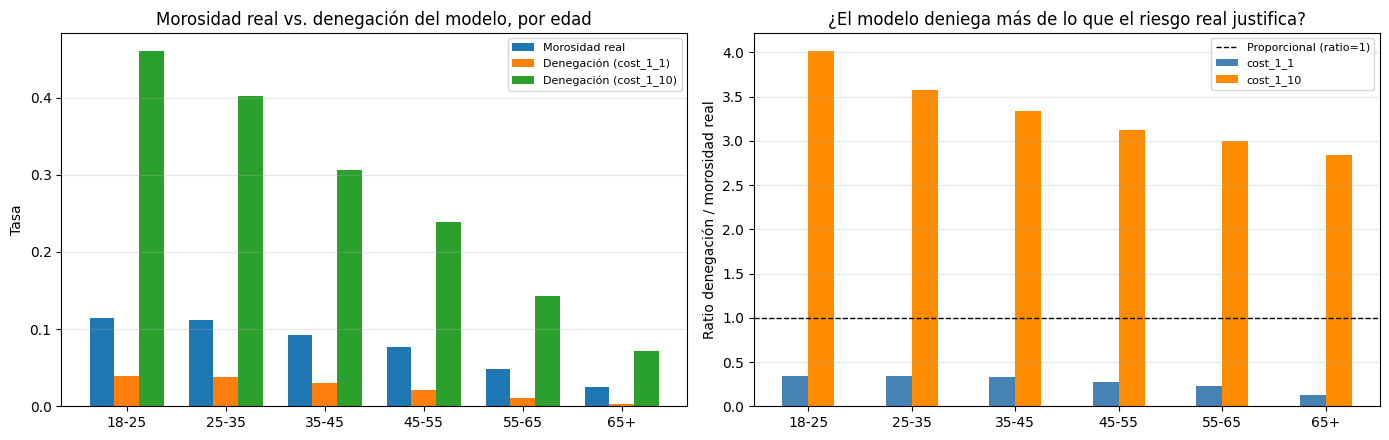

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x_pos = np.arange(len(age_bias_summary))
width = 0.25

axes[0].bar(x_pos - width, age_bias_summary["tasa_morosidad_real"], width, label="Morosidad real")
axes[0].bar(x_pos, age_bias_summary["tasa_denegacion_cost_1_1"], width, label="Denegación (cost_1_1)")
axes[0].bar(x_pos + width, age_bias_summary["tasa_denegacion_cost_1_10"], width, label="Denegación (cost_1_10)")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(age_bias_summary["age_group"])
axes[0].set_ylabel("Tasa")
axes[0].set_title("Morosidad real vs. denegación del modelo, por edad")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x_pos - width/2, age_bias_summary["ratio_1_1"], width, label="cost_1_1", color="steelblue")
axes[1].bar(x_pos + width/2, age_bias_summary["ratio_1_10"], width, label="cost_1_10", color="darkorange")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1, label="Proporcional (ratio=1)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(age_bias_summary["age_group"])
axes[1].set_ylabel("Ratio denegación / morosidad real")
axes[1].set_title("¿El modelo deniega más de lo que el riesgo real justifica?")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Los gráficos muestran cómo varía la tasa de denegación del modelo según la edad y cómo se compara con la morosidad real observada en cada grupo. En el escenario **cost_1_1**, el modelo mantiene una política relativamente permisiva, con tasas de denegación inferiores a la tasa real de morosidad en todos los rangos de edad. Sin embargo, al utilizar el escenario **cost_1_10**, donde los falsos negativos tienen un coste mucho mayor, el modelo adopta un comportamiento considerablemente más conservador y aumenta de forma significativa el número de denegaciones, especialmente entre los clientes más jóvenes.

El gráfico de la derecha cuantifica este efecto mediante el cociente entre la tasa de denegación y la tasa real de morosidad. Mientras que en **cost_1_1** este ratio permanece por debajo de 1, indicando que el modelo deniega menos operaciones de las que sugeriría la tasa de impago, en **cost_1_10** el ratio oscila entre aproximadamente 2.8 y 4.0. Esto significa que, para minimizar el elevado coste asociado a los falsos negativos, el modelo acepta incrementar notablemente el número de falsos positivos, denegando un volumen de solicitudes muy superior al que justificaría únicamente la morosidad histórica.

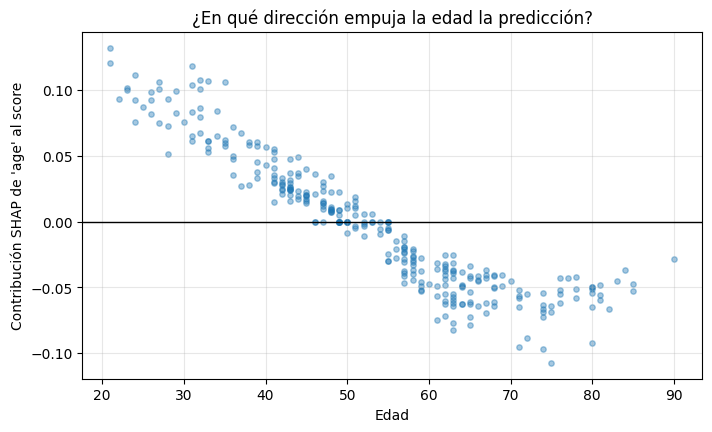

In [ ]:
# Relación entre edad y su propia contribución SHAP, usando la muestra ya
# explicada en la sección 5 (no hace falta recalcular SHAP).
if SHAP_AVAILABLE and shap_values_array is not None:
    age_col_idx = FEATURES.index("age")
    age_shap_df = pd.DataFrame({
        "age": explain_sample["age"].values,
        "shap_age": shap_values_array[:, age_col_idx],
    }).sort_values("age")

    plt.figure(figsize=(8, 4.5))
    plt.scatter(age_shap_df["age"], age_shap_df["shap_age"], alpha=0.4, s=15)
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Edad")
    plt.ylabel("Contribución SHAP de 'age' al score")
    plt.title("¿En qué dirección empuja la edad la predicción?")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("SHAP no disponible en este entorno; se omite el gráfico de dependencia de edad.")


El gráfico representa la contribución local de la variable **edad** a la predicción del modelo mediante los valores SHAP. Se observa una relación claramente decreciente: para los clientes más jóvenes, la edad presenta contribuciones SHAP positivas, aumentando la probabilidad estimada de impago, mientras que a medida que la edad aumenta dichas contribuciones disminuyen progresivamente hasta hacerse negativas alrededor de los 50 años. A partir de esa edad, ser más mayor reduce de forma consistente la probabilidad predicha de impago, alcanzando las mayores contribuciones negativas entre los clientes de mayor edad. Este comportamiento indica que el modelo ha aprendido que, manteniendo constantes el resto de variables, la juventud se asocia a un mayor riesgo crediticio, mientras que una mayor edad actúa como un factor protector. Además, la transición suave alrededor de los 50 años sugiere que el modelo utiliza la edad como una variable continua, sin introducir umbrales artificiales o cambios bruscos en la predicción.

## 9. Limitaciones y decisiones metodológicas

Antes de las conclusiones finales, dejamos explícitas las simplificaciones asumidas en esta auditoría, para que no parezcan descuidos:

- **`KernelExplainer` con `nsamples=100`**: es una aproximación rápida, no la más precisa posible. Con más muestras (p. ej. 1000+) las estimaciones de SHAP serían más estables, a costa de mucho más tiempo de cómputo. Se eligió 100 por tiempo disponible, no porque sea el valor óptimo.
- **Búsqueda de contrafactuales greedy**: cambia una variable a la vez (la de mayor impacto en cada paso), hasta un máximo de 4 cambios. No explora combinaciones de variables ni garantiza el contrafactual más "cercano" en un sentido formal (p. ej. distancia mínima ponderada). El enunciado no exige ninguna herramienta concreta para esto ("otras técnicas que los estudiantes consideren oportunas"); existen librerías como `alibi` que ofrecen contrafactuales por optimización con más garantías formales, pero se ha optado por una implementación propia, más simple y transparente de auditar, suficiente para lo que pide el enunciado ("¿qué información le damos a un cliente que pregunta por qué se le deniega el crédito?").
- **Comprobación de sesgo casera, no con librería de fairness**: la sección 8 usa una métrica propia (ratio denegación/morosidad real) en vez de métricas estándar de fairness (demographic parity, equalized odds, disparate impact con `fairlearn` o `aequitas`). Es un análisis honesto y con base real, pero no sigue un marco de fairness formal ni se ha comprobado con más variables protegidas (género, etc. — no disponibles en este dataset).
- **El árbol subrogado tiene profundidad 3** por legibilidad; un árbol más profundo tendría mayor fidelidad pero perdería la ventaja de ser explicable "de un vistazo".

Ninguna de estas decisiones invalida los hallazgos anteriores, pero sí acota su alcance: esta auditoría da una base sólida y honesta, no un análisis de fairness o de robustez exhaustivo a nivel de producción real.


## 10. Conclusiones de la auditoría

La auditoría del MLP, seleccionado como modelo de producción en ambos escenarios de coste en el notebook 02, muestra que, a pesar de tratarse de una red neuronal, su comportamiento resulta razonablemente interpretable mediante distintas técnicas de explicabilidad global y local. El árbol subrogado consigue aproximar una gran parte de las decisiones del modelo, indicando que, aunque la arquitectura interna sea compleja, gran parte de las reglas aprendidas pueden resumirse mediante relaciones relativamente sencillas entre unas pocas variables. Esto facilita la comprensión del modelo y aumenta la confianza en su utilización dentro de un contexto financiero.

Las distintas técnicas de interpretabilidad empleadas presentan además un elevado grado de coherencia entre sí. Tanto la importancia por permutación como SHAP identifican de forma consistente que las variables relacionadas con el historial de morosidad (`NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTime30-59DaysPastDueNotWorse` y `TotalPastDueEvents`) constituyen los principales determinantes de la predicción. La utilización de las líneas de crédito (`RevolvingUtilizationOfUnsecuredLines`) aparece igualmente como uno de los factores más relevantes, actuando como un indicador adicional de tensión financiera. El análisis mediante gráficos de dependencia parcial confirma estas conclusiones: la probabilidad estimada de impago aumenta de forma monótona con la utilización del crédito y con el número de retrasos, aunque estos últimos presentan un claro efecto de saturación, de manera que los primeros episodios de morosidad incrementan notablemente el riesgo mientras que retrasos adicionales producen incrementos progresivamente menores.

La edad merece una consideración específica. Aunque no aparece entre las variables más importantes del modelo, el análisis local mediante SHAP revela un comportamiento perfectamente interpretable: clientes jóvenes reciben contribuciones positivas que aumentan la probabilidad de impago, mientras que clientes de mayor edad presentan contribuciones negativas que actúan como factor protector. La transición se produce de forma gradual alrededor de los 50 años, sin observarse saltos bruscos ni umbrales artificiales, lo que indica que el modelo ha aprendido una relación continua entre edad y riesgo. No obstante, esta relación debe interpretarse únicamente como una asociación aprendida a partir de los datos históricos y no como una relación causal.

La auditoría por grupos de edad muestra igualmente un comportamiento consistente con el objetivo de negocio. En ambos escenarios, la tasa de denegación disminuye conforme aumenta la edad, siguiendo la misma tendencia observada en la morosidad real. Bajo el escenario `cost_1_1`, el modelo mantiene una política relativamente permisiva y la tasa de denegación permanece incluso por debajo de la tasa de impago observada. En cambio, cuando el coste de los falsos negativos aumenta (`cost_1_10`), el modelo adopta una política claramente más conservadora, incrementando significativamente las denegaciones, especialmente entre los clientes jóvenes. El ratio entre denegaciones y morosidad real alcanza valores comprendidos aproximadamente entre 2.8 y 4.0, reflejando que el modelo acepta incrementar el número de falsos positivos con el objetivo de minimizar el riesgo de conceder crédito a clientes que posteriormente incumplan sus obligaciones.

Las explicaciones locales mediante SHAP muestran un elevado grado de consistencia con las conclusiones globales. Los casos correctamente clasificados como clientes de alto riesgo presentan siempre importantes contribuciones positivas procedentes de múltiples variables de morosidad, reforzadas habitualmente por una elevada utilización del crédito. Por el contrario, los falsos negativos analizados corresponden a clientes sin antecedentes significativos de impago, donde la ausencia de señales históricas de morosidad conduce al modelo a estimar un riesgo reducido. Esta coherencia entre explicaciones globales y locales constituye una evidencia adicional de que el modelo está aprendiendo patrones razonables desde el punto de vista financiero.

El análisis contrafactual aporta además una interpretación muy intuitiva de las decisiones del modelo. En clientes clasificados como de alto riesgo resulta necesario modificar simultáneamente varias variables relacionadas con la morosidad y, en muchos casos, reducir también la utilización del crédito para conseguir que la predicción cambie a cliente solvente. Por el contrario, en los falsos negativos basta frecuentemente con introducir un pequeño número de episodios de retraso para que el modelo pase a clasificarlos como clientes de riesgo. La comparación entre ambos escenarios de coste muestra además un comportamiento especialmente interesante: en `cost_1_10` las predicciones positivas se vuelven más robustas y requieren modificar un mayor número de variables para revertirse, mientras que identificar un cliente como potencialmente moroso exige una menor evidencia que en el escenario balanceado. Es decir, el cambio de función de coste no altera qué variables considera importantes el modelo, sino la robustez de sus decisiones y el nivel de evidencia necesario para cambiar de clase.

En conjunto, todos los análisis realizados —importancia global, SHAP, dependencia parcial, auditoría por grupos, explicaciones locales y contrafactuales— cuentan una historia completamente consistente. El modelo basa sus decisiones principalmente en indicadores objetivos relacionados con el historial de pagos y la utilización del crédito, variables que cualquier analista de riesgo consideraría relevantes. La coherencia observada entre las distintas técnicas de interpretabilidad aumenta la confianza en el comportamiento aprendido por la red neuronal y demuestra que, pese a tratarse de un modelo no lineal, sus decisiones pueden explicarse de forma comprensible y alineada con el conocimiento experto del dominio financiero.

No obstante, conviene señalar algunas limitaciones. Las explicaciones SHAP se han obtenido sobre un subconjunto representativo de observaciones para mantener tiempos de ejecución razonables, mientras que la generación de contrafactuales utiliza un procedimiento heurístico que no garantiza encontrar la solución óptima global. Asimismo, la auditoría de sesgo se ha centrado únicamente en la variable edad y no constituye una evaluación completa de fairness. Estas limitaciones no afectan a las conclusiones principales del trabajo, pero representan posibles líneas de mejora para una futura implantación en un entorno productivo.